# Countix Dataset Exploration

This notebook analyzes annotations and verifies media files for the Countix dataset. It focuses on analyzing the video files and visual repetitions.

## 1. Setup

Place the notebook in the project root, next to `annotations/` and `videos/`. Edit the paths below only if your layout differs.


In [29]:
from pathlib import Path
from urllib.parse import quote
import html
import json
import re
import uuid

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

SPLIT_ORDER = ["train", "val", "test"]
SPLIT_COLORS = {"train": "#2563eb", "val": "#f59e0b", "test": "#10b981"}
VIDEO_SUFFIXES = {".mp4", ".mkv", ".webm", ".mov", ".m4v", ".avi"}

In [30]:
ANNOTATIONS_DIR = Path("annotations")
VIDEO_ROOT = Path("videos")

print(f"Annotations: {ANNOTATIONS_DIR.resolve()}")
print(f"Videos:      {VIDEO_ROOT.resolve()}")


Annotations: /mnt/Workspace/audiovisual-video-repetition-counting/data/Countix/annotations
Videos:      /mnt/Workspace/audiovisual-video-repetition-counting/data/Countix/videos


## 2. Load and prepare annotations

Each row identifies a Kinetics clip and one annotated repetition window. The absolute repetition timestamps are also converted to positions relative to the local Kinetics clip.


In [31]:
REQUIRED_COLUMNS = [
    "video_name",
    "count",
    "fps",
    "repetition_segment_start_sec",
    "repetition_segment_end_sec",
]


def find_split_csv(directory, split):
    preferred = [
        directory / f"Countix_{split}.csv",
        directory / f"CountixAV_{split}.csv",
        directory / f"countixav_{split}.csv",
        directory / f"countixAV_{split}.csv",
        directory / f"{split}.csv",
    ]
    for path in preferred:
        if path.is_file():
            return path
    matches = sorted(
        path
        for path in directory.glob("*.csv")
        if split in path.stem.lower() and "local" not in path.stem.lower()
    )
    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected one annotation CSV for '{split}' in {directory}; found {len(matches)}."
        )
    return matches[0]


def time_token(value):
    value = float(value)
    if value.is_integer():
        return f"{int(value):06d}"
    return f"{value:.6f}".rstrip("0").rstrip(".").replace(".", "p")


def make_clip_stem(video_id, start, end):
    return f"{video_id}_{time_token(start)}_{time_token(end)}"


def extract_original_info(video_name):
    # Extract video_id, kinetics_start, and kinetics_end from video_name
    stem = str(video_name).rsplit(".", 1)[0]
    parts = stem.split("_")
    if len(parts) > 2:
        vid_id = "_".join(parts[:-2])
        try:
            k_start = float(parts[-2].replace("p", "."))
            k_end = float(parts[-1].replace("p", "."))
            return vid_id, k_start, k_end
        except ValueError:
            pass
    return stem, 0.0, 0.0


datasets = {}
annotation_paths = {}
for split in SPLIT_ORDER:
    path = find_split_csv(ANNOTATIONS_DIR, split)
    frame = pd.read_csv(path).copy()
    
    missing = set(REQUIRED_COLUMNS) - set(frame.columns)
    if missing:
        raise ValueError(f"{path}: missing columns: {', '.join(sorted(missing))}")
        
    numeric_cols = ["count", "fps", "repetition_segment_start_sec", "repetition_segment_end_sec"]
    for column in numeric_cols:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
        
    frame["split"] = split
    frame["row_in_split"] = np.arange(len(frame))
    
    # Reconstruct original columns by parsing the filename
    parsed_info = frame["video_name"].apply(extract_original_info)
    frame["video_id"] = parsed_info.apply(lambda x: x[0])
    frame["kinetics_start"] = parsed_info.apply(lambda x: x[1])
    frame["kinetics_end"] = parsed_info.apply(lambda x: x[2])
    
    # Reconstruct absolute repetition times
    frame["repetition_start"] = frame["kinetics_start"] + frame["repetition_segment_start_sec"]
    frame["repetition_end"] = frame["kinetics_start"] + frame["repetition_segment_end_sec"]
    
    frame["source_video_id"] = frame["video_id"].astype(str)
    
    # clip_stem is the filename without extension
    frame["clip_stem"] = frame["video_name"].apply(lambda x: str(x).rsplit(".", 1)[0])
    
    datasets[split] = frame
    annotation_paths[split] = path

annotations = pd.concat(datasets.values(), ignore_index=True, sort=False)
annotations["split"] = pd.Categorical(
    annotations["split"], SPLIT_ORDER, ordered=True
)

# Recompute derivatives expected by downstream cells
annotations["kinetics_duration_sec"] = (
    annotations["kinetics_end"] - annotations["kinetics_start"]
)

# Map the new segment columns back to the expected local_sec columns
annotations["repetition_start_local_sec"] = annotations["repetition_segment_start_sec"]
annotations["repetition_end_local_sec"] = annotations["repetition_segment_end_sec"]

annotations["repetition_duration_sec"] = (
    annotations["repetition_end_local_sec"] - annotations["repetition_start_local_sec"]
)
annotations["repetition_coverage"] = (
    annotations["repetition_duration_sec"] / annotations["kinetics_duration_sec"]
)
annotations["mean_cycle_duration_sec"] = (
    annotations["repetition_duration_sec"] / annotations["count"]
)

print(
    f"Loaded {len(annotations):,} annotation rows representing "
    f"{annotations['clip_stem'].nunique():,} unique Kinetics clips."
)

Loaded 7,732 annotation rows representing 6,967 unique Kinetics clips.


## 3. Dataset overview

The summary distinguishes annotation rows, Kinetics clips, and original YouTube IDs. Multiple rows may refer to the same clip.


In [32]:
overview = (
    annotations.groupby("split", observed=True)
    .agg(
        annotation_rows=("video_id", "size"),
        unique_kinetics_clips=("clip_stem", "nunique"),
        unique_source_videos=("source_video_id", "nunique"),
        annotated_repetitions=("count", "sum"),
        median_count=("count", "median"),
        maximum_count=("count", "max"),
        median_kinetics_duration_sec=("kinetics_duration_sec", "median"),
        median_repetition_window_sec=("repetition_duration_sec", "median"),
        median_repetition_coverage=("repetition_coverage", "median"),
    )
    .reindex(SPLIT_ORDER)
)

total = pd.DataFrame(
    {
        "annotation_rows": [len(annotations)],
        "unique_kinetics_clips": [annotations["clip_stem"].nunique()],
        "unique_source_videos": [annotations["source_video_id"].nunique()],
        "annotated_repetitions": [annotations["count"].sum()],
        "median_count": [annotations["count"].median()],
        "maximum_count": [annotations["count"].max()],
        "median_kinetics_duration_sec": [annotations["kinetics_duration_sec"].median()],
        "median_repetition_window_sec": [annotations["repetition_duration_sec"].median()],
        "median_repetition_coverage": [annotations["repetition_coverage"].median()],
    },
    index=["all"],
)
overview_with_total = pd.concat([overview, total])
display(overview_with_total.round(3))


,annotation_rows,unique_kinetics_clips,unique_source_videos,annotated_repetitions,median_count,maximum_count,median_kinetics_duration_sec,median_repetition_window_sec,median_repetition_coverage
train,3763,3394,3373,26950,4.000,71,10.000,6.100,0.610
val,1432,1269,1252,8773,4.000,56,10.000,5.655,0.566
test,2537,2312,2303,16455,4.000,68,10.000,6.060,0.607
all,7732,6967,6924,52178,4.000,71,10.000,6.025,0.603


### Annotation distributions

These plots show dataset size, repetition counts, and how much of each Kinetics clip is covered by the annotated repetitive action.


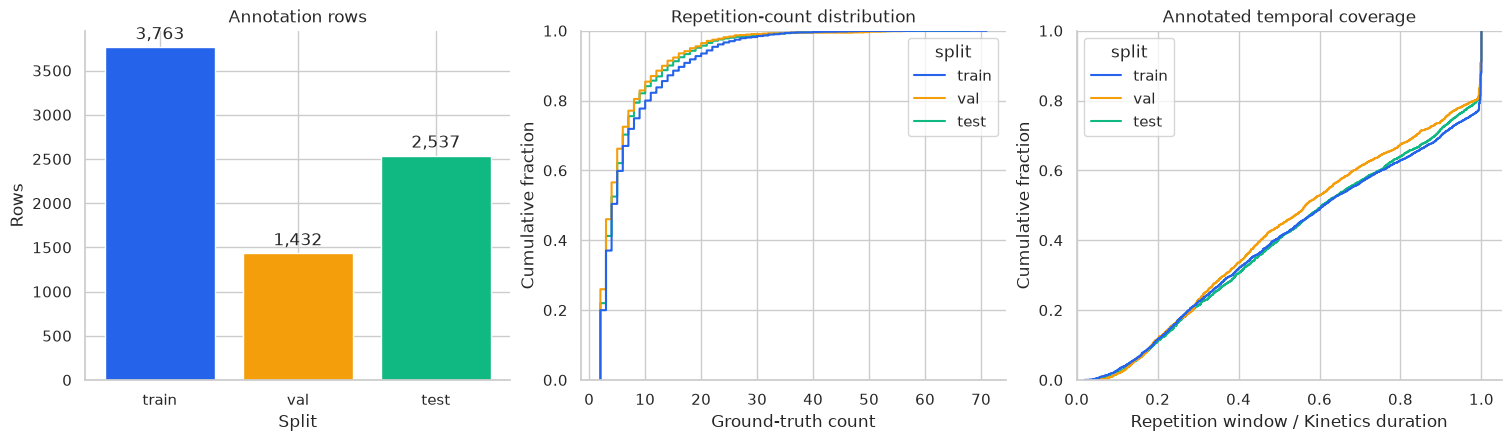

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), constrained_layout=True)

split_sizes = annotations["split"].value_counts(sort=False).reindex(SPLIT_ORDER)
axes[0].bar(
    split_sizes.index,
    split_sizes.values,
    color=[SPLIT_COLORS[split] for split in SPLIT_ORDER],
)
axes[0].bar_label(axes[0].containers[0], fmt="{:,.0f}", padding=3)
axes[0].set(title="Annotation rows", xlabel="Split", ylabel="Rows")

sns.ecdfplot(
    data=annotations,
    x="count",
    hue="split",
    hue_order=SPLIT_ORDER,
    palette=SPLIT_COLORS,
    ax=axes[1],
)
axes[1].set(
    title="Repetition-count distribution",
    xlabel="Ground-truth count",
    ylabel="Cumulative fraction",
)

sns.ecdfplot(
    data=annotations,
    x="repetition_coverage",
    hue="split",
    hue_order=SPLIT_ORDER,
    palette=SPLIT_COLORS,
    ax=axes[2],
)
axes[2].set(
    title="Annotated temporal coverage",
    xlabel="Repetition window / Kinetics duration",
    ylabel="Cumulative fraction",
)
axes[2].set_xlim(0, max(1.05, annotations["repetition_coverage"].quantile(0.995)))

sns.despine()
plt.show()


## 4. Video inventory

Files are matched by the 11-character YouTube ID and the two Kinetics timestamps. Additional filename fields are ignored.


In [34]:
def media_lookup_key(filename):
    stem = Path(filename).stem
    if len(stem) < 12 or stem[11] != "_":
        return None
    fields = stem[12:].split("_")
    if len(fields) < 2:
        return None
    try:
        start = round(float(fields[0].replace("p", ".")), 6)
        end = round(float(fields[1].replace("p", ".")), 6)
    except ValueError:
        return None
    return stem[:11], start, end

def build_media_index(root, suffixes):
    index = {}
    if not root.is_dir():
        return index
    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in suffixes:
            key = media_lookup_key(path.name)
            if key is not None:
                index.setdefault(key, []).append(path)
    for paths in index.values():
        paths.sort()
    return index

def row_lookup_key(row):
    return (
        str(row["video_id"]),
        round(float(row["kinetics_start"]), 6),
        round(float(row["kinetics_end"]), 6),
    )

def choose_path(paths, clip_stem):
    if not paths:
        return None
    return sorted(paths, key=lambda path: (path.stem != clip_stem, str(path)))[0]

video_index = build_media_index(VIDEO_ROOT, VIDEO_SUFFIXES)

unique_clips = (
    annotations[
        [
            "clip_stem",
            "video_id",
            "kinetics_start",
            "kinetics_end",
            "kinetics_duration_sec",
        ]
    ]
    .drop_duplicates("clip_stem")
    .reset_index(drop=True)
)

inventory_rows = []
for _, row in unique_clips.iterrows():
    key = row_lookup_key(row)
    video_path = choose_path(video_index.get(key, []), row["clip_stem"])
    record = {
        "clip_stem": row["clip_stem"],
        "video_path": video_path,
        "video_available": video_path is not None,
        "video_matches": len(video_index.get(key, [])),
        "expected_duration_sec": row["kinetics_duration_sec"],
    }
    inventory_rows.append(record)

media_inventory = pd.DataFrame(inventory_rows)

clip_split_inventory = (
    annotations[["split", "clip_stem"]]
    .drop_duplicates()
    .merge(media_inventory, on="clip_stem", how="left")
)

video_overview = (
    clip_split_inventory.groupby("split", observed=True)
    .agg(
        expected_clips=("clip_stem", "size"),
        videos_found=("video_available", "sum"),
    )
    .reindex(SPLIT_ORDER)
)
video_overview["video_coverage"] = (
    video_overview["videos_found"] / video_overview["expected_clips"]
)
display(video_overview.round(3))

,expected_clips,videos_found,video_coverage
split,,,
train,3394,3394,1.000
val,1269,1269,1.000
test,2312,2312,1.000


## 5. Annotation and media checks

These checks cover timestamp validity, duplicate annotations, cross-split overlap, missing media, WAV readability, and audiovisual duration alignment.


In [35]:
invalid_kinetics = annotations["kinetics_end"].le(annotations["kinetics_start"])
invalid_repetition = annotations["repetition_end"].le(annotations["repetition_start"])
repetition_outside_kinetics = (
    annotations["repetition_start"].lt(annotations["kinetics_start"] - 0.05)
    | annotations["repetition_end"].gt(annotations["kinetics_end"] + 0.05)
)
invalid_count = annotations["count"].le(0) | annotations["count"].isna()
clip_split_counts = annotations.groupby("clip_stem", observed=True)["split"].nunique()

checks = pd.DataFrame(
    {
        "diagnostic": [
            "Rows with missing required values",
            "Rows with invalid Kinetics intervals",
            "Rows with invalid repetition intervals",
            "Repetition windows outside Kinetics bounds",
            "Rows with non-positive counts",
            "Exact duplicate annotation rows",
            "Kinetics clips present in multiple splits",
            "Expected clips without a video",
        ],
        "affected": [
            int(annotations[REQUIRED_COLUMNS].isna().any(axis=1).sum()),
            int(invalid_kinetics.sum()),
            int(invalid_repetition.sum()),
            int(repetition_outside_kinetics.sum()),
            int(invalid_count.sum()),
            int(annotations.duplicated(subset=REQUIRED_COLUMNS).sum()),
            int(clip_split_counts.gt(1).sum()),
            int((~media_inventory["video_available"]).sum()),
        ],
    }
)
display(checks)

missing_videos = media_inventory.loc[
    ~media_inventory["video_available"], ["clip_stem"]
].reset_index(drop=True)

,diagnostic,affected
0,Rows with missing required values,0
1,Rows with invalid Kinetics intervals,0
2,Rows with invalid repetition intervals,0
3,Repetition windows outside Kinetics bounds,0
4,Rows with non-positive counts,0
5,Exact duplicate annotation rows,2
6,Kinetics clips present in multiple splits,8
7,Expected clips without a video,0


## 6. Select examples

The table selects low-, median-, and high-count annotations from each split.


In [36]:
annotations_with_media = annotations.merge(
    media_inventory[
        ["clip_stem", "video_available", "video_path"]
    ],
    on="clip_stem",
    how="left",
)

example_rows = []
for split in SPLIT_ORDER:
    split_frame = annotations_with_media.loc[
        annotations_with_media["split"].eq(split)
    ].copy()
    complete = split_frame.loc[
        split_frame["video_available"]
    ]
    candidates = complete if len(complete) else split_frame
    candidates = candidates.sort_values("count")
    if not len(candidates):
        continue
    positions = {
        "low count": 0,
        "median count": len(candidates) // 2,
        "high count": len(candidates) - 1,
    }
    for label, position in positions.items():
        row = candidates.iloc[position]
        example_rows.append(
            {
                "split": split,
                "selection": label,
                "row_in_split": int(row["row_in_split"]),
                "clip_stem": row["clip_stem"],
                "count": row["count"],
                "repetition_window_sec": row["repetition_duration_sec"],
                "video": bool(row["video_available"]),
            }
        )

examples = pd.DataFrame(example_rows)
display(examples)

,split,selection,row_in_split,clip_stem,count,repetition_window_sec,video
0,train,low count,3666,1TbjMYvZqjw_000042_000052,2,6.030,True
1,train,median count,60,hEk_hUf5SrM_000000_000010,4,5.770,True
2,train,high count,2023,pXbB4cK3CJ4_000128_000138,71,10.000,True
3,val,low count,1391,IV6k74QpWUs_000003_000013,2,3.900,True
4,val,median count,324,5qAS5ieSlXY_000117_000127,4,10.000,True
5,val,high count,567,J2tL2BtKydA_000001_000011,56,10.000,True
6,test,low count,34,3tIXySyb2Vw_000025_000035,2,2.200,True
7,test,median count,212,7i51NXFfF10_000000_000010,4,2.240,True
8,test,high count,1766,0p6HskFO3bc_000001_000011,68,9.980,True


## 7. Synchronized video and annotation

Video and the associated highlighted region shows the annotated repetition window.


In [37]:
def get_annotation_row(split="train", row_number=0):
    frame = annotations_with_media.loc[annotations_with_media["split"].eq(split)]
    if not 0 <= row_number < len(frame):
        raise IndexError(
            f"row_number must be between 0 and {len(frame) - 1} for {split}."
        )
    return frame.iloc[row_number]


def notebook_relative_url(path):
    try:
        relative = Path(path).resolve().relative_to(Path.cwd().resolve())
    except ValueError:
        return None
    return quote(relative.as_posix(), safe="/")


def show_countix_example(split="train", row_number=0):
    row = get_annotation_row(split, row_number)
    video_path = row.get("video_path")
    if not isinstance(video_path, Path) or not video_path.is_file():
        print(f"Video not found for {row['clip_stem']}")
        return

    video_url = notebook_relative_url(video_path)
    if video_url is None:
        print("The video is outside the Jupyter server root.")
        print("Start Jupyter from the project root or one of its parents.")
        return

    # Il metadato del browser sostituirà la durata esatta del video appena caricato.
    annotation_duration = float(row.get("kinetics_duration_sec", 0))
    duration = annotation_duration if annotation_duration > 0 else 10.0

    fps = float(row.get("fps", 30.0))
    repetition_start = max(0.0, float(row["repetition_start_local_sec"]))
    repetition_end = min(duration, float(row["repetition_end_local_sec"]))
    window_left = 100 * repetition_start / duration
    window_width = 100 * (repetition_end - repetition_start) / duration

    action_class = str(row.get("class", "unknown"))
    video_filename = str(row.get("video_name", video_path.name))

    count_val = int(round(float(row.get("count", 0))))
    repetition_blocks_html = ""
    
    if count_val > 0 and fps > 0:
        segment_start_sec = repetition_start
        segment_end_sec = repetition_end
        total_segment_duration = segment_end_sec - segment_start_sec
        
        if total_segment_duration > 0:
            segment_start_frame = float(
                row.get("repetition_segment_start_frame", row.get("segment_start_frame", 0))
            )
            for i in range(1, count_val + 1):
                frame_pair = None
                for start_frame_key, end_frame_key in (
                    (f"rep_{i}_start_frame", f"rep_{i}_end_frame"),
                    (f"rep_start_frame_{i}", f"rep_end_frame_{i}"),
                ):
                    if (
                        start_frame_key in row
                        and end_frame_key in row
                        and pd.notna(row[start_frame_key])
                        and pd.notna(row[end_frame_key])
                    ):
                        frame_pair = (
                            float(row[start_frame_key]),
                            float(row[end_frame_key]),
                        )
                        break
                
                if frame_pair is not None:
                    f_start, f_end = frame_pair
                    rep_s = segment_start_sec + (f_start - segment_start_frame) / fps
                    rep_e = segment_start_sec + (f_end - segment_start_frame) / fps
                else:
                    rep_s = segment_start_sec + (i - 1) * total_segment_duration / count_val
                    rep_e = segment_start_sec + i * total_segment_duration / count_val
                
                rep_left = max(0.0, 100 * rep_s / duration)
                rep_w = max(0.0, 100 * (rep_e - rep_s) / duration)
                
                repetition_blocks_html += f'''
                  <div class="single-repetition" data-start="{rep_s:.9f}" data-end="{rep_e:.9f}" style="left: {rep_left:.4f}%; width: {rep_w:.4f}%;" title="Rep {i}">
                    <span>{i}</span>
                  </div>
                '''

    uid = f"countixav-{uuid.uuid4().hex}"
    player = f'''
    <div id="{uid}" class="countixav-player" data-duration="{duration:.9f}"
         data-repetition-start="{repetition_start:.9f}"
         data-repetition-end="{repetition_end:.9f}">
      <style>
        #{uid} {{ max-width:1000px; font-family:system-ui,sans-serif; color:#f8fafc; background:#1e293b; padding:16px; border-radius:12px; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1); }}
        #{uid} .meta {{ display:flex; flex-wrap:wrap; gap:10px 20px; margin:0 0 12px; font-size:14px; background:#0f172a; padding:10px 14px; border-radius:8px; border: 1px solid #334155; }}
        #{uid} .meta span {{ color:#e2e8f0; }}
        #{uid} .meta strong {{ font-weight:600; color:#38bdf8; }}
        #{uid} video {{ display:block; width:100%; max-height:560px; background:#000000; border-radius:8px; }}
        #{uid} .track-label {{ margin-top:12px; color:#cbd5e1; font-size:13px; font-weight:600; }}
        #{uid} .timeline {{ position:relative; height:42px; margin-top:4px; border-radius:8px; overflow:hidden; background:#334155; cursor:pointer; }}
        #{uid} .repetition-window {{ position:absolute; top:0; bottom:0; left:{window_left:.6f}%; width:{window_width:.6f}%; display:flex; align-items:center; justify-content:center; overflow:hidden; background:rgba(245,158,11,0.2); border-left:1px dashed #f59e0b; border-right:1px dashed #f59e0b; }}
        #{uid} .single-repetition {{ position:absolute; top:2px; bottom:2px; background:#f59e0b; border:1px solid #b45309; border-radius:3px; display:flex; align-items:center; justify-content:center; box-sizing: border-box; }}
        #{uid} .single-repetition span {{ color:#0f172a; font-size:10px; font-weight:700; white-space:nowrap; overflow:hidden; text-overflow:ellipsis; padding:0 2px; }}
        #{uid} .timeline-playhead {{ position:absolute; z-index:3; top:0; bottom:0; width:3px; left:0; background:#ef4444; box-shadow:0 0 0 1px rgba(255,255,255,.75); pointer-events:none; }}
        #{uid} .axis {{ display:flex; justify-content:space-between; margin-top:4px; color:#94a3b8; font-size:12px; }}
        #{uid} .status {{ margin-top:6px; color:#e2e8f0; font-size:13px; min-height:20px; font-weight:500; }}
      </style>
      <div class="meta">
        <span><strong>Clip:</strong> {html.escape(str(row['clip_stem']))}</span>
        <span><strong>Video File:</strong> {html.escape(video_filename)}</span>
        <span><strong>Action Class:</strong> {html.escape(action_class)}</span>
        <span><strong>Split:</strong> {html.escape(str(row['split']))}</span>
        <span><strong>Count:</strong> {float(row['count']):g}</span>
        <span><strong>Window:</strong> {repetition_start:.3f}–{repetition_end:.3f} s</span>
      </div>
      <video controls preload="metadata" src="{video_url}"></video>
      
      <div class="track-label">Annotated repetitions breakdown</div>
      <div class="timeline" role="slider" aria-label="Annotated repetition timeline"
           aria-valuemin="0" aria-valuemax="{duration:.3f}" aria-valuenow="0">
        <div class="repetition-window"></div>
        {repetition_blocks_html}
        <div class="timeline-playhead" aria-hidden="true"></div>
      </div>
      <div class="axis"><span>0 s</span><span class="axis-end">{duration:.3f} s</span></div>
      <div class="status" aria-live="polite">0.000 s · before the annotated window</div>
      
      <script>
        (() => {{
          const root = document.getElementById({json.dumps(uid)});
          const video = root.querySelector('video');
          const timeline = root.querySelector('.timeline');
          const timelinePlayhead = root.querySelector('.timeline-playhead');
          const repetitionWindow = root.querySelector('.repetition-window');
          const repetitionBlocks = root.querySelectorAll('.single-repetition');
          const axisEnds = root.querySelectorAll('.axis-end');
          const status = root.querySelector('.status');
          
          let duration = Number(root.dataset.duration);
          const repetitionStart = Number(root.dataset.repetitionStart);
          const repetitionEnd = Number(root.dataset.repetitionEnd);
          let animationFrame = null;

          const layoutRange = (element, start, end) => {{
            const safeStart = Math.min(Math.max(start, 0), duration);
            const safeEnd = Math.min(Math.max(end, safeStart), duration);
            element.style.left = `${{100 * safeStart / duration}}%`;
            element.style.width = `${{100 * (safeEnd - safeStart) / duration}}%`;
          }};

          const layoutTracks = () => {{
            layoutRange(repetitionWindow, repetitionStart, repetitionEnd);
            repetitionBlocks.forEach(block => {{
              layoutRange(block, Number(block.dataset.start), Number(block.dataset.end));
            }});
            timeline.setAttribute('aria-valuemax', duration.toFixed(3));
            axisEnds.forEach(label => {{
              label.textContent = `${{duration.toFixed(3)}} s`;
            }});
          }};

          const useVideoDuration = () => {{
            const measuredDuration = Number(video.duration);
            if (Number.isFinite(measuredDuration) && measuredDuration > 0) {{
              duration = measuredDuration;
              root.dataset.duration = measuredDuration.toFixed(9);
              layoutTracks();
            }}
          }};

          const update = () => {{
            const t = Math.min(Math.max(video.currentTime || 0, 0), duration);
            timelinePlayhead.style.left = `${{100 * t / duration}}%`;
            timeline.setAttribute('aria-valuenow', t.toFixed(3));
            
            if (t < repetitionStart) {{
              status.textContent = `${{t.toFixed(3)}} s · before the annotated window`;
            }} else if (t <= repetitionEnd) {{
              status.textContent = `${{t.toFixed(3)}} s · inside the annotated window`;
            }} else {{
              status.textContent = `${{t.toFixed(3)}} s · after the annotated window`;
            }}
          }};

          const animate = () => {{
            update();
            if (!video.paused && !video.ended) {{
              animationFrame = requestAnimationFrame(animate);
            }}
          }};

          const seekFromTrack = (event, track) => {{
            const bounds = track.getBoundingClientRect();
            video.currentTime = duration * (event.clientX - bounds.left) / bounds.width;
            update();
          }};
          
          timeline.addEventListener('click', event => seekFromTrack(event, timeline));
          
          video.addEventListener('play', () => {{
            if (animationFrame !== null) cancelAnimationFrame(animationFrame);
            animate();
          }});
          
          video.addEventListener('pause', update);
          video.addEventListener('ended', update);
          video.addEventListener('seeked', update);
          
          video.addEventListener('loadedmetadata', () => {{
            useVideoDuration();
            update();
          }});
          
          layoutTracks();
          update();
        }})();
      </script>
    </div>
    '''
    display(HTML(player))

In [38]:
def get_annotation_row(split="train", row_number=0):
    frame = annotations_with_media.loc[annotations_with_media["split"].eq(split)]
    if not 0 <= row_number < len(frame):
        raise IndexError(
            f"row_number must be between 0 and {len(frame) - 1} for {split}."
        )
    return frame.iloc[row_number]


def notebook_relative_url(path):
    try:
        relative = Path(path).resolve().relative_to(Path.cwd().resolve())
    except ValueError:
        return None
    return quote(relative.as_posix(), safe="/")


def show_countix_example(split="train", row_number=0):
    row = get_annotation_row(split, row_number)
    video_path = row.get("video_path")
    if not isinstance(video_path, Path) or not video_path.is_file():
        print(f"Video not found for {row['clip_stem']}")
        return

    video_url = notebook_relative_url(video_path)
    if video_url is None:
        print("The video is outside the Jupyter server root.")
        print("Start Jupyter from the project root or one of its parents.")
        return

    # Il metadato del browser sostituirà la durata esatta del video appena caricato.
    annotation_duration = float(row.get("kinetics_duration_sec", 0))
    duration = annotation_duration if annotation_duration > 0 else 10.0

    fps = float(row.get("fps", 30.0))
    repetition_start = max(0.0, float(row["repetition_start_local_sec"]))
    repetition_end = min(duration, float(row["repetition_end_local_sec"]))
    window_left = 100 * repetition_start / duration
    window_width = 100 * (repetition_end - repetition_start) / duration

    action_class = str(row.get("class", "unknown"))
    video_filename = str(row.get("video_name", video_path.name))

    count_val = int(round(float(row.get("count", 0))))
    repetition_blocks_html = ""
    
    if count_val > 0 and fps > 0:
        segment_start_sec = repetition_start
        segment_end_sec = repetition_end
        total_segment_duration = segment_end_sec - segment_start_sec
        
        if total_segment_duration > 0:
            segment_start_frame = float(
                row.get("repetition_segment_start_frame", row.get("segment_start_frame", 0))
            )
            for i in range(1, count_val + 1):
                frame_pair = None
                for start_frame_key, end_frame_key in (
                    (f"rep_{i}_start_frame", f"rep_{i}_end_frame"),
                    (f"rep_start_frame_{i}", f"rep_end_frame_{i}"),
                ):
                    if (
                        start_frame_key in row
                        and end_frame_key in row
                        and pd.notna(row[start_frame_key])
                        and pd.notna(row[end_frame_key])
                    ):
                        frame_pair = (
                            float(row[start_frame_key]),
                            float(row[end_frame_key]),
                        )
                        break
                
                if frame_pair is not None:
                    f_start, f_end = frame_pair
                    rep_s = segment_start_sec + (f_start - segment_start_frame) / fps
                    rep_e = segment_start_sec + (f_end - segment_start_frame) / fps
                else:
                    rep_s = segment_start_sec + (i - 1) * total_segment_duration / count_val
                    rep_e = segment_start_sec + i * total_segment_duration / count_val
                
                rep_left = max(0.0, 100 * rep_s / duration)
                rep_w = max(0.0, 100 * (rep_e - rep_s) / duration)
                
                repetition_blocks_html += f'''
                  <div class="single-repetition" data-start="{rep_s:.9f}" data-end="{rep_e:.9f}" style="left: {rep_left:.4f}%; width: {rep_w:.4f}%;" title="Rep {i}">
                    <span>{i}</span>
                  </div>
                '''

    uid = f"countixav-{uuid.uuid4().hex}"
    player = f'''
    <div id="{uid}" class="countixav-player" data-duration="{duration:.9f}"
         data-repetition-start="{repetition_start:.9f}"
         data-repetition-end="{repetition_end:.9f}">
      <style>
        #{uid} {{ max-width:1000px; font-family:system-ui,sans-serif; color:#f8fafc; background:#1e293b; padding:16px; border-radius:12px; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1); }}
        #{uid} .meta {{ display:flex; flex-wrap:wrap; gap:10px 20px; margin:0 0 12px; font-size:14px; background:#0f172a; padding:10px 14px; border-radius:8px; border: 1px solid #334155; }}
        #{uid} .meta span {{ color:#e2e8f0; }}
        #{uid} .meta strong {{ font-weight:600; color:#38bdf8; }}
        #{uid} video {{ display:block; width:100%; max-height:560px; background:#000000; border-radius:8px; }}
        #{uid} .track-label {{ margin-top:12px; color:#cbd5e1; font-size:13px; font-weight:600; }}
        #{uid} .timeline {{ position:relative; height:42px; margin-top:4px; border-radius:8px; overflow:hidden; background:#334155; cursor:pointer; }}
        #{uid} .repetition-window {{ position:absolute; top:0; bottom:0; left:{window_left:.6f}%; width:{window_width:.6f}%; display:flex; align-items:center; justify-content:center; overflow:hidden; background:rgba(245,158,11,0.2); border-left:1px dashed #f59e0b; border-right:1px dashed #f59e0b; }}
        #{uid} .single-repetition {{ position:absolute; top:2px; bottom:2px; background:#f59e0b; border:1px solid #b45309; border-radius:3px; display:flex; align-items:center; justify-content:center; box-sizing: border-box; }}
        #{uid} .single-repetition span {{ color:#0f172a; font-size:10px; font-weight:700; white-space:nowrap; overflow:hidden; text-overflow:ellipsis; padding:0 2px; }}
        #{uid} .timeline-playhead {{ position:absolute; z-index:3; top:0; bottom:0; width:3px; left:0; background:#ef4444; box-shadow:0 0 0 1px rgba(255,255,255,.75); pointer-events:none; }}
        #{uid} .axis {{ display:flex; justify-content:space-between; margin-top:4px; color:#94a3b8; font-size:12px; }}
        #{uid} .status {{ margin-top:6px; color:#e2e8f0; font-size:13px; min-height:20px; font-weight:500; }}
      </style>
      <div class="meta">
        <span><strong>Clip:</strong> {html.escape(str(row['clip_stem']))}</span>
        <span><strong>Video File:</strong> {html.escape(video_filename)}</span>
        <span><strong>Action Class:</strong> {html.escape(action_class)}</span>
        <span><strong>Split:</strong> {html.escape(str(row['split']))}</span>
        <span><strong>Count:</strong> {float(row['count']):g}</span>
        <span><strong>Window:</strong> {repetition_start:.3f}–{repetition_end:.3f} s</span>
      </div>
      <video controls preload="metadata" src="{video_url}"></video>
      
      <div class="track-label">Annotated repetitions breakdown</div>
      <div class="timeline" role="slider" aria-label="Annotated repetition timeline"
           aria-valuemin="0" aria-valuemax="{duration:.3f}" aria-valuenow="0">
        <div class="repetition-window"></div>
        {repetition_blocks_html}
        <div class="timeline-playhead" aria-hidden="true"></div>
      </div>
      <div class="axis"><span>0 s</span><span class="axis-end">{duration:.3f} s</span></div>
      <div class="status" aria-live="polite">0.000 s · before the annotated window</div>
      
      <script>
        (() => {{
          const root = document.getElementById({json.dumps(uid)});
          const video = root.querySelector('video');
          const timeline = root.querySelector('.timeline');
          const timelinePlayhead = root.querySelector('.timeline-playhead');
          const repetitionWindow = root.querySelector('.repetition-window');
          const repetitionBlocks = root.querySelectorAll('.single-repetition');
          const axisEnds = root.querySelectorAll('.axis-end');
          const status = root.querySelector('.status');
          
          let duration = Number(root.dataset.duration);
          const repetitionStart = Number(root.dataset.repetitionStart);
          const repetitionEnd = Number(root.dataset.repetitionEnd);
          let animationFrame = null;

          const layoutRange = (element, start, end) => {{
            const safeStart = Math.min(Math.max(start, 0), duration);
            const safeEnd = Math.min(Math.max(end, safeStart), duration);
            element.style.left = `${{100 * safeStart / duration}}%`;
            element.style.width = `${{100 * (safeEnd - safeStart) / duration}}%`;
          }};

          const layoutTracks = () => {{
            layoutRange(repetitionWindow, repetitionStart, repetitionEnd);
            repetitionBlocks.forEach(block => {{
              layoutRange(block, Number(block.dataset.start), Number(block.dataset.end));
            }});
            timeline.setAttribute('aria-valuemax', duration.toFixed(3));
            axisEnds.forEach(label => {{
              label.textContent = `${{duration.toFixed(3)}} s`;
            }});
          }};

          const useVideoDuration = () => {{
            const measuredDuration = Number(video.duration);
            if (Number.isFinite(measuredDuration) && measuredDuration > 0) {{
              duration = measuredDuration;
              root.dataset.duration = measuredDuration.toFixed(9);
              layoutTracks();
            }}
          }};

          const update = () => {{
            const t = Math.min(Math.max(video.currentTime || 0, 0), duration);
            timelinePlayhead.style.left = `${{100 * t / duration}}%`;
            timeline.setAttribute('aria-valuenow', t.toFixed(3));
            
            if (t < repetitionStart) {{
              status.textContent = `${{t.toFixed(3)}} s · before the annotated window`;
            }} else if (t <= repetitionEnd) {{
              status.textContent = `${{t.toFixed(3)}} s · inside the annotated window`;
            }} else {{
              status.textContent = `${{t.toFixed(3)}} s · after the annotated window`;
            }}
          }};

          const animate = () => {{
            update();
            if (!video.paused && !video.ended) {{
              animationFrame = requestAnimationFrame(animate);
            }}
          }};

          const seekFromTrack = (event, track) => {{
            const bounds = track.getBoundingClientRect();
            video.currentTime = duration * (event.clientX - bounds.left) / bounds.width;
            update();
          }};
          
          timeline.addEventListener('click', event => seekFromTrack(event, timeline));
          
          video.addEventListener('play', () => {{
            if (animationFrame !== null) cancelAnimationFrame(animationFrame);
            animate();
          }});
          
          video.addEventListener('pause', update);
          video.addEventListener('ended', update);
          video.addEventListener('seeked', update);
          
          video.addEventListener('loadedmetadata', () => {{
            useVideoDuration();
            update();
          }});
          
          layoutTracks();
          update();
        }})();
      </script>
    </div>
    '''
    display(HTML(player))

`EXAMPLE_ROW` refers to the original row order within the selected split. The browser must be able to serve both the notebook and media files from the same Jupyter root.


In [39]:
# Change these two values to inspect another annotation row.
EXAMPLE_SPLIT = "train"
EXAMPLE_ROW = 1778

show_countix_example(EXAMPLE_SPLIT, EXAMPLE_ROW)


In [40]:
from pathlib import Path
import shutil
import subprocess
import tempfile

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Video, display


EXPORT_COUNTIX_MP4 = True
COUNTIX_EXPORT_DIR = Path("canva_exports")


def export_countix_example_mp4(
    split=EXAMPLE_SPLIT,
    row_number=EXAMPLE_ROW,
    output_dir=COUNTIX_EXPORT_DIR,
    output_fps=24,
    output_width=1280,
    video_height=720,
    panel_height=170,
    crf=23,
):
    """Export the selected Countix example with its repetition timeline."""

    def probe_duration(path, ffprobe_executable):
        result = subprocess.run(
            [
                ffprobe_executable,
                "-v",
                "error",
                "-show_entries",
                "format=duration",
                "-of",
                "default=noprint_wrappers=1:nokey=1",
                str(path),
            ],
            capture_output=True,
            text=True,
            check=False,
        )
        if result.returncode != 0:
            return float("nan")
        try:
            duration_value = float(result.stdout.strip())
        except (TypeError, ValueError):
            return float("nan")
        return duration_value if np.isfinite(duration_value) and duration_value > 0 else float("nan")

    def finite_float(value, default=float("nan")):
        try:
            result = float(value)
        except (TypeError, ValueError):
            return default
        return result if np.isfinite(result) else default

    def first_finite(row, names, default=float("nan")):
        for name in names:
            if name in row:
                value = finite_float(row.get(name))
                if np.isfinite(value):
                    return value
        return default

    def repetition_frame_pair(row, repetition_index):
        alternatives = (
            (
                f"rep_start_frame_{repetition_index}",
                f"rep_end_frame_{repetition_index}",
            ),
            (
                f"rep_{repetition_index}_start_frame",
                f"rep_{repetition_index}_end_frame",
            ),
        )
        for start_name, end_name in alternatives:
            start_frame = finite_float(row.get(start_name))
            end_frame = finite_float(row.get(end_name))
            if np.isfinite(start_frame) and np.isfinite(end_frame):
                return start_frame, end_frame
        return None

    ffmpeg = shutil.which("ffmpeg")
    ffprobe = shutil.which("ffprobe")
    if ffmpeg is None or ffprobe is None:
        raise RuntimeError("FFmpeg and FFprobe must be available in PATH.")
    if output_fps <= 0 or output_width <= 0 or video_height <= 0 or panel_height <= 0:
        raise ValueError("Output dimensions and output_fps must be positive.")

    row = get_annotation_row(split, row_number)
    video_value = row.get("video_path")
    video_path = Path(video_value) if video_value is not None else None
    if video_path is None or not video_path.is_file():
        raise FileNotFoundError(f"Video not found for row {row_number} in split {split!r}.")

    duration = probe_duration(video_path, ffprobe)
    if not np.isfinite(duration):
        duration = finite_float(row.get("kinetics_duration_sec"))
    if not np.isfinite(duration) or duration <= 0:
        raise ValueError(f"Cannot determine a valid duration for {video_path.name}.")

    repetition_start = first_finite(
        row,
        ("repetition_start_local_sec", "repetition_segment_start_sec"),
        default=0.0,
    )
    repetition_end = first_finite(
        row,
        ("repetition_end_local_sec", "repetition_segment_end_sec"),
        default=duration,
    )
    repetition_start = float(np.clip(repetition_start, 0.0, duration))
    repetition_end = float(np.clip(repetition_end, repetition_start, duration))

    count_value = max(0, int(round(finite_float(row.get("count"), 0.0))))
    metadata_fps = finite_float(row.get("fps"), 0.0)
    segment_start_frame = first_finite(
        row,
        ("segment_start_frame", "repetition_segment_start_frame"),
        default=0.0,
    )
    repetition_window_duration = repetition_end - repetition_start

    repetition_intervals = []
    if count_value > 0 and repetition_window_duration > 0:
        for repetition_index in range(1, count_value + 1):
            frame_pair = repetition_frame_pair(row, repetition_index)
            if frame_pair is not None and metadata_fps > 0:
                start_frame, end_frame = frame_pair
                interval_start = repetition_start + (
                    start_frame - segment_start_frame
                ) / metadata_fps
                interval_end = repetition_start + (
                    end_frame - segment_start_frame
                ) / metadata_fps
            else:
                interval_start = repetition_start + (
                    (repetition_index - 1)
                    * repetition_window_duration
                    / count_value
                )
                interval_end = repetition_start + (
                    repetition_index * repetition_window_duration / count_value
                )

            interval_start = float(np.clip(interval_start, 0.0, duration))
            interval_end = float(np.clip(interval_end, interval_start, duration))
            if interval_end > interval_start:
                repetition_intervals.append(
                    (repetition_index, interval_start, interval_end)
                )

    clip_stem = str(row.get("clip_stem") or video_path.stem)
    action_class = str(row.get("class") or "unknown")
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{clip_stem}_annotated.mp4"

    # Geometry of the timeline panel appended below the video.
    track_left_px = 40
    track_right_px = 40
    track_width_px = output_width - track_left_px - track_right_px
    timeline_top_px = 60
    timeline_height_px = 54

    with tempfile.TemporaryDirectory(prefix="countix_export_") as temp_dir:
        panel_path = Path(temp_dir) / "timeline.png"

        figure = plt.figure(
            figsize=(output_width / 100, panel_height / 100),
            dpi=100,
            facecolor="#1e293b",
        )
        timeline_axis = figure.add_axes(
            [
                track_left_px / output_width,
                (panel_height - timeline_top_px - timeline_height_px) / panel_height,
                track_width_px / output_width,
                timeline_height_px / panel_height,
            ]
        )
        timeline_axis.set_facecolor("#334155")
        timeline_axis.axvspan(
            repetition_start,
            repetition_end,
            color="#f59e0b",
            alpha=0.20,
            linewidth=0,
        )
        timeline_axis.axvline(
            repetition_start,
            color="#f59e0b",
            linewidth=1.5,
            linestyle="--",
        )
        timeline_axis.axvline(
            repetition_end,
            color="#f59e0b",
            linewidth=1.5,
            linestyle="--",
        )

        for repetition_index, interval_start, interval_end in repetition_intervals:
            timeline_axis.axvspan(
                interval_start,
                interval_end,
                ymin=0.06,
                ymax=0.94,
                facecolor="#f59e0b",
                edgecolor="#b45309",
                linewidth=1,
                alpha=1.0,
            )
            timeline_axis.text(
                (interval_start + interval_end) / 2,
                0.5,
                str(repetition_index),
                ha="center",
                va="center",
                color="#0f172a",
                fontsize=10,
                fontweight="bold",
                clip_on=True,
            )

        timeline_axis.set(xlim=(0, duration), ylim=(0, 1), xticks=[], yticks=[])
        for spine in timeline_axis.spines.values():
            spine.set_visible(False)

        left_x = track_left_px / output_width
        right_x = (track_left_px + track_width_px) / output_width
        figure.text(
            left_x,
            0.83,
            f"Annotated repetitions | class: {action_class} | count: {count_value}",
            color="#cbd5e1",
            fontsize=10,
            fontweight="bold",
        )
        figure.text(left_x, 0.18, "0 s", color="#94a3b8", fontsize=9)
        figure.text(
            right_x,
            0.18,
            f"{duration:.3f} s",
            color="#94a3b8",
            fontsize=9,
            ha="right",
        )
        figure.text(
            left_x,
            0.04,
            f"Annotated window: {repetition_start:.3f}–{repetition_end:.3f} s",
            color="#94a3b8",
            fontsize=9,
        )
        figure.savefig(
            panel_path,
            dpi=100,
            facecolor=figure.get_facecolor(),
            edgecolor="none",
        )
        plt.close(figure)

        cursor_x = (
            f"{float(track_left_px):.1f}"
            f"+(t/{duration:.9f})*{float(track_width_px):.1f}"
        )
        cursor_y = video_height + timeline_top_px
        filter_graph = (
            f"[0:v]trim=duration={duration:.9f},setpts=PTS-STARTPTS,"
            f"fps={int(output_fps)},"
            f"scale={output_width}:{video_height}:force_original_aspect_ratio=decrease,"
            f"pad={output_width}:{video_height}:(ow-iw)/2:(oh-ih)/2:color=0x0b1020,"
            "format=yuv420p[video];"
            f"[1:v]setpts=PTS-STARTPTS,fps={int(output_fps)},"
            f"scale={output_width}:{panel_height},format=yuv420p[panel];"
            "[video][panel]vstack=inputs=2:shortest=1[base];"
            f"color=c=0xef4444:s=4x{timeline_height_px}:"
            f"r={int(output_fps)}:d={duration:.9f}[cursor];"
            f"[base][cursor]overlay=x='{cursor_x}':y={cursor_y}:shortest=1[outv]"
        )

        command = [
            ffmpeg,
            "-y",
            "-i",
            str(video_path),
            "-loop",
            "1",
            "-framerate",
            str(int(output_fps)),
            "-i",
            str(panel_path),
            "-filter_complex",
            filter_graph,
            "-map",
            "[outv]",
            "-an",
            "-t",
            f"{duration:.9f}",
            "-r",
            str(int(output_fps)),
            "-c:v",
            "libx264",
            "-preset",
            "fast",
            "-crf",
            str(int(crf)),
            "-pix_fmt",
            "yuv420p",
            "-movflags",
            "+faststart",
            str(output_path),
        ]
        result = subprocess.run(command, capture_output=True, text=True, check=False)
        if result.returncode != 0:
            raise RuntimeError("FFmpeg export failed:\n" + result.stderr[-5000:])

    print(f"Saved MP4: {output_path.resolve()}")
    return output_path


if EXPORT_COUNTIX_MP4:
    COUNTIX_MP4_PATH = export_countix_example_mp4()
    display(Video(filename=str(COUNTIX_MP4_PATH), embed=False, html_attributes="controls"))
else:
    print("Set EXPORT_COUNTIX_MP4 = True and run this cell to create the MP4.")

Saved MP4: /mnt/Workspace/audiovisual-video-repetition-counting/data/Countix/canva_exports/dCIX9Ocwab0_000000_000010_annotated.mp4


In [41]:
# Three visual exemplars for the example selected with EXAMPLE_SPLIT/EXAMPLE_ROW.
# Run this cell after the cells that define annotations_with_media and
# get_annotation_row.

from pathlib import Path
from urllib.parse import quote
import html
import json
import re
import shutil
import subprocess

import numpy as np
from IPython.display import HTML, display


VISUAL_EXEMPLARS_DIR = Path("visual_exemplars")
VISUAL_EXEMPLAR_WIDTH = 420
VISUAL_EXEMPLAR_HEIGHT = 236
VISUAL_EXEMPLAR_CRF = 22
VISUAL_EXEMPLAR_RANDOM_SEED = 7
REBUILD_VISUAL_EXEMPLARS = False

# Leave these as None for automatic selection. Manual examples: 4 and (2, 7).
SELECTED_VIDEO_REPETITION = None
PEER_VIDEO_REPETITIONS = None


def show_three_visual_exemplars(
    split=EXAMPLE_SPLIT,
    row_number=EXAMPLE_ROW,
    selected_repetition=SELECTED_VIDEO_REPETITION,
    peer_repetitions=PEER_VIDEO_REPETITIONS,
    output_dir=VISUAL_EXEMPLARS_DIR,
    width=VISUAL_EXEMPLAR_WIDTH,
    height=VISUAL_EXEMPLAR_HEIGHT,
    crf=VISUAL_EXEMPLAR_CRF,
    random_seed=VISUAL_EXEMPLAR_RANDOM_SEED,
    rebuild=REBUILD_VISUAL_EXEMPLARS,
):
    """Display one selected-video repetition and two distinct same-class peers."""

    def finite_float(value, default=float("nan")):
        try:
            result = float(value)
        except (TypeError, ValueError):
            return default
        return result if np.isfinite(result) else default

    def video_path_from_row(row):
        value = row.get("video_path")
        if value is None:
            return None
        path = Path(value)
        return path if path.is_file() else None

    def frame_columns(row, repetition_number):
        # Support both conventions encountered in the Countix notebook/scripts.
        alternatives = (
            (
                f"rep_{repetition_number}_start_frame",
                f"rep_{repetition_number}_end_frame",
            ),
            (
                f"rep_start_frame_{repetition_number}",
                f"rep_end_frame_{repetition_number}",
            ),
        )
        for start_column, end_column in alternatives:
            if start_column in row and end_column in row:
                return start_column, end_column
        return None

    def valid_repetitions(row):
        repetition_numbers = set()
        for column in row.index:
            name = str(column)
            match = re.fullmatch(r"rep_(\d+)_start_frame", name)
            if match:
                repetition_numbers.add(int(match.group(1)))
                continue
            match = re.fullmatch(r"rep_start_frame_(\d+)", name)
            if match:
                repetition_numbers.add(int(match.group(1)))

        repetitions = []
        for repetition_number in sorted(repetition_numbers):
            pair = frame_columns(row, repetition_number)
            if pair is None:
                continue
            start_frame = finite_float(row.get(pair[0]))
            end_frame = finite_float(row.get(pair[1]))
            if (
                np.isfinite(start_frame)
                and np.isfinite(end_frame)
                and start_frame >= 0
                and end_frame > start_frame
            ):
                repetitions.append(
                    {
                        "number": repetition_number,
                        "start_frame": int(round(start_frame)),
                        "end_frame": int(round(end_frame)),
                    }
                )
        return repetitions

    def choose_repetition(repetitions, requested, description):
        by_number = {item["number"]: item for item in repetitions}
        if requested is not None:
            requested = int(requested)
            if requested not in by_number:
                raise ValueError(
                    f"Repetition {requested} is unavailable for {description}; "
                    f"available: {sorted(by_number)}"
                )
            return by_number[requested]
        return repetitions[len(repetitions) // 2]

    def probe_display_rotation(path):
        """Return the counter-clockwise display rotation reported by FFprobe."""
        result = subprocess.run(
            [
                ffprobe,
                "-v",
                "error",
                "-select_streams",
                "v:0",
                "-show_streams",
                "-of",
                "json",
                str(path),
            ],
            capture_output=True,
            text=True,
            check=False,
        )
        if result.returncode != 0:
            raise RuntimeError(
                f"FFprobe could not inspect the orientation of {path.name}: "
                f"{result.stderr[-2000:]}"
            )
        try:
            payload = json.loads(result.stdout)
            stream = payload.get("streams", [])[0]
        except (json.JSONDecodeError, IndexError, TypeError) as exc:
            raise RuntimeError(
                f"FFprobe returned invalid orientation data for {path.name}."
            ) from exc

        # Modern containers normally expose rotation through a display matrix.
        for side_data in stream.get("side_data_list", []):
            rotation = finite_float(side_data.get("rotation"))
            if np.isfinite(rotation):
                return rotation

        # Older files may store it as a stream tag instead.
        rotation = finite_float(stream.get("tags", {}).get("rotate"), 0.0)
        return rotation if np.isfinite(rotation) else 0.0

    def explicit_orientation_filter(rotation):
        """Build a physical quarter-turn filter and its normalized angle."""
        normalized = float(rotation) % 360.0
        quarter_turn = int(round(normalized / 90.0)) % 4
        snapped = float(quarter_turn * 90)
        angular_error = min(
            abs(normalized - snapped),
            abs(normalized - snapped + 360.0),
            abs(normalized - snapped - 360.0),
        )
        if angular_error > 1.0:
            raise ValueError(
                f"Unsupported non-quarter-turn display rotation: {rotation:g} degrees."
            )
        filters = {
            0: "",
            1: "transpose=cclock,",
            2: "hflip,vflip,",
            3: "transpose=clock,",
        }
        return filters[quarter_turn], snapped

    def extract_exemplar(row, repetition, role):
        source_path = video_path_from_row(row)
        if source_path is None:
            raise FileNotFoundError(
                f"Video not found for {row.get('video_name', row.get('clip_stem', '?'))}"
            )

        fps = finite_float(row.get("fps"))
        if not np.isfinite(fps) or fps <= 0:
            raise ValueError(f"Invalid FPS for {source_path.name}: {row.get('fps')!r}")

        repetition_number = repetition["number"]
        start_frame = repetition["start_frame"]
        end_frame = repetition["end_frame"]
        frame_count = end_frame - start_frame
        clip_stem = str(row.get("clip_stem") or source_path.stem)
        safe_stem = re.sub(r"[^A-Za-z0-9_.-]+", "_", clip_stem)
        source_rotation = probe_display_rotation(source_path)
        orientation_filter, normalized_rotation = explicit_orientation_filter(
            source_rotation
        )
        output_name = (
            f"{safe_stem}_rep{repetition_number:03d}_"
            f"f{start_frame}-{end_frame}_rot{int(normalized_rotation):03d}_"
            f"normv2_{width}x{height}.mp4"
        )
        output_path = output_dir / output_name

        if rebuild or not output_path.is_file() or output_path.stat().st_size == 0:
            # MPEG-TS deliberately discards the input container's display matrix,
            # keeping this procedure compatible with older FFmpeg releases.
            temporary_transport = output_path.with_name(
                f".{output_path.stem}.orientation-normalized.ts"
            )
            temporary_transport.unlink(missing_ok=True)
            output_path.unlink(missing_ok=True)

            # end_frame is exclusive: [start_frame, end_frame).
            video_filter = (
                f"trim=start_frame={start_frame}:end_frame={end_frame},"
                f"setpts=N/({fps:.12g}*TB),"
                f"{orientation_filter}"
                f"scale={width}:{height}:force_original_aspect_ratio=decrease,"
                f"pad={width}:{height}:(ow-iw)/2:(oh-ih)/2:color=black,"
                "format=yuv420p"
            )
            command = [
                ffmpeg,
                "-y",
                "-noautorotate",
                "-i",
                str(source_path),
                "-vf",
                video_filter,
                "-frames:v",
                str(frame_count),
                "-an",
                "-c:v",
                "libx264",
                "-preset",
                "fast",
                "-crf",
                str(int(crf)),
                "-pix_fmt",
                "yuv420p",
                "-f",
                "mpegts",
                "-muxdelay",
                "0",
                str(temporary_transport),
            ]
            try:
                result = subprocess.run(
                    command,
                    capture_output=True,
                    text=True,
                    check=False,
                )
                if result.returncode != 0:
                    raise RuntimeError(
                        f"FFmpeg extraction failed for {source_path.name}, "
                        f"repetition {repetition_number}:\n{result.stderr[-4000:]}"
                    )
                if (
                    not temporary_transport.is_file()
                    or temporary_transport.stat().st_size == 0
                ):
                    raise RuntimeError(
                        f"FFmpeg did not create the normalized intermediate clip "
                        f"for {source_path.name}."
                    )

                # Remuxing the metadata-free transport stream creates a browser-
                # friendly MP4 that cannot be rotated a second time by its player.
                remux_command = [
                    ffmpeg,
                    "-y",
                    "-fflags",
                    "+genpts",
                    "-i",
                    str(temporary_transport),
                    "-map",
                    "0:v:0",
                    "-c:v",
                    "copy",
                    "-metadata:s:v:0",
                    "rotate=0",
                    "-avoid_negative_ts",
                    "make_zero",
                    "-movflags",
                    "+faststart",
                    str(output_path),
                ]
                remux_result = subprocess.run(
                    remux_command,
                    capture_output=True,
                    text=True,
                    check=False,
                )
                if remux_result.returncode != 0:
                    raise RuntimeError(
                        f"FFmpeg MP4 remux failed for {source_path.name}, "
                        f"repetition {repetition_number}:\n"
                        f"{remux_result.stderr[-4000:]}"
                    )
            except Exception:
                output_path.unlink(missing_ok=True)
                raise
            finally:
                temporary_transport.unlink(missing_ok=True)

            if not output_path.is_file() or output_path.stat().st_size == 0:
                raise RuntimeError(f"FFmpeg did not create {output_path}")

        return {
            "role": role,
            "path": output_path,
            "source_name": source_path.name,
            "split": str(row.get("split", "unknown")),
            "class": str(row.get("class", "unknown")),
            "repetition": repetition_number,
            "start_frame": start_frame,
            "end_frame": end_frame,
            "duration": frame_count / fps,
            "source_rotation": source_rotation,
        }

    def notebook_url(path):
        try:
            relative = path.resolve().relative_to(Path.cwd().resolve())
        except ValueError as exc:
            raise RuntimeError(
                "The exemplar output directory must be inside the Jupyter server root."
            ) from exc
        cache_token = path.stat().st_mtime_ns
        return f"{quote(relative.as_posix(), safe='/')}?v={cache_token}"

    ffmpeg = shutil.which("ffmpeg")
    ffprobe = shutil.which("ffprobe")
    if ffmpeg is None or ffprobe is None:
        raise RuntimeError("FFmpeg and FFprobe were not found in PATH.")
    if width <= 0 or height <= 0 or width % 2 or height % 2:
        raise ValueError("width and height must be positive even integers.")

    selected_row = get_annotation_row(split, row_number)
    selected_video_path = video_path_from_row(selected_row)
    if selected_video_path is None:
        raise FileNotFoundError(
            f"Selected video not found for row {row_number} in split {split!r}."
        )

    selected_class = str(selected_row.get("class", "unknown")).strip()
    selected_valid_repetitions = valid_repetitions(selected_row)
    if not selected_valid_repetitions:
        raise ValueError("The selected annotation has no valid repetitions.")
    selected_exemplar_repetition = choose_repetition(
        selected_valid_repetitions,
        selected_repetition,
        "the selected video",
    )

    # Search all splits for another physical video with the same class.
    class_mask = (
        annotations_with_media["class"]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq(selected_class.casefold())
    )
    candidates_by_path = {}
    for _, candidate_row in annotations_with_media.loc[class_mask].iterrows():
        candidate_path = video_path_from_row(candidate_row)
        if candidate_path is None:
            continue
        if candidate_path.resolve() == selected_video_path.resolve():
            continue
        repetitions = valid_repetitions(candidate_row)
        if repetitions:
            candidates_by_path.setdefault(
                str(candidate_path.resolve()),
                (candidate_row, repetitions),
            )

    candidate_rows = list(candidates_by_path.values())

    if len(candidate_rows) < 2:
        raise ValueError(
            f"Two distinct peer videos with valid repetitions are required for "
            f"class {selected_class!r}; found {len(candidate_rows)}."
        )

    # The seed keeps the two peer-video choices reproducible across runs.
    rng = np.random.default_rng(random_seed)
    peer_positions = rng.choice(len(candidate_rows), size=2, replace=False)
    selected_peers = [candidate_rows[int(position)] for position in peer_positions]

    if peer_repetitions is None:
        requested_peer_repetitions = (None, None)
    else:
        requested_peer_repetitions = tuple(peer_repetitions)
        if len(requested_peer_repetitions) != 2:
            raise ValueError("peer_repetitions must contain exactly two values.")

    peer_exemplars = []
    for peer_index, ((peer_row, repetitions), requested) in enumerate(
        zip(selected_peers, requested_peer_repetitions),
        start=1,
    ):
        peer_repetition = choose_repetition(
            repetitions,
            requested,
            f"same-class video {peer_index}",
        )
        peer_exemplars.append((peer_row, peer_repetition))

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    exemplars = [
        extract_exemplar(
            selected_row,
            selected_exemplar_repetition,
            "Selected video",
        ),
        extract_exemplar(
            peer_exemplars[0][0],
            peer_exemplars[0][1],
            "Same-class video 1",
        ),
        extract_exemplar(
            peer_exemplars[1][0],
            peer_exemplars[1][1],
            "Same-class video 2",
        ),
    ]

    cards = []
    for exemplar in exemplars:
        source_label = html.escape(exemplar["source_name"])
        split_label = html.escape(exemplar["split"])
        role_label = html.escape(exemplar["role"])
        cards.append(
            f"""
            <div class="visual-exemplar-card">
              <video autoplay loop muted playsinline controls preload="metadata"
                     src="{notebook_url(exemplar['path'])}"></video>
              <div class="visual-exemplar-role">{role_label}</div>
              <div class="visual-exemplar-source" title="{source_label}">
                {source_label}
              </div>
              <div class="visual-exemplar-details">
                split: {split_label}<br>
                repetition {exemplar['repetition']} · frames
                [{exemplar['start_frame']}, {exemplar['end_frame']}) ·
                {exemplar['duration']:.3f} s ·
                normalized rotation {exemplar['source_rotation']:g}°
              </div>
            </div>
            """
        )

    uid = f"visual-exemplars-{abs(hash((split, row_number, selected_class)))}"
    display(
        HTML(
            f"""
            <div id="{uid}" class="visual-exemplars-root">
              <style>
                #{uid} {{
                  max-width: 1400px;
                  padding: 16px;
                  border-radius: 12px;
                  background: #0f172a;
                  color: #e2e8f0;
                  font-family: system-ui, sans-serif;
                }}
                #{uid} .visual-exemplars-title {{
                  margin: 0 0 12px;
                  font-size: 16px;
                  font-weight: 700;
                }}
                #{uid} .visual-exemplars-grid {{
                  display: grid;
                  grid-template-columns: repeat(3, minmax(0, 1fr));
                  gap: 12px;
                }}
                #{uid} .visual-exemplar-card {{
                  min-width: 0;
                  padding: 10px;
                  border: 1px solid #334155;
                  border-radius: 9px;
                  background: #1e293b;
                }}
                #{uid} video {{
                  display: block;
                  width: 100%;
                  aspect-ratio: {width} / {height};
                  object-fit: contain;
                  border-radius: 6px;
                  background: #000;
                }}
                #{uid} .visual-exemplar-role {{
                  margin-top: 9px;
                  color: #38bdf8;
                  font-size: 13px;
                  font-weight: 700;
                }}
                #{uid} .visual-exemplar-source {{
                  margin-top: 3px;
                  overflow: hidden;
                  color: #f8fafc;
                  font-size: 12px;
                  text-overflow: ellipsis;
                  white-space: nowrap;
                }}
                #{uid} .visual-exemplar-details {{
                  margin-top: 5px;
                  color: #94a3b8;
                  font-size: 11px;
                  line-height: 1.45;
                }}
                @media (max-width: 900px) {{
                  #{uid} .visual-exemplars-grid {{
                    grid-template-columns: 1fr;
                  }}
                }}
              </style>
              <div class="visual-exemplars-title">
                Three visual exemplars · class: {html.escape(selected_class)}
              </div>
              <div class="visual-exemplars-grid">
                {''.join(cards)}
              </div>
            </div>
            """
        )
    )

    print("Generated visual-exemplar clips:")
    for exemplar in exemplars:
        print(" -", exemplar["path"].resolve())

    return exemplars


VISUAL_EXEMPLARS = show_three_visual_exemplars(
    random_seed=23,
)


Generated visual-exemplar clips:
 - /mnt/Workspace/audiovisual-video-repetition-counting/data/Countix/visual_exemplars/dCIX9Ocwab0_000000_000010_rep004_f150-200_rot000_normv2_420x236.mp4
 - /mnt/Workspace/audiovisual-video-repetition-counting/data/Countix/visual_exemplars/KaRLbZkgXYQ_000045_000055_rep007_f150-175_rot000_normv2_420x236.mp4
 - /mnt/Workspace/audiovisual-video-repetition-counting/data/Countix/visual_exemplars/FQn6pVdKmmk_000015_000025_rep002_f89-177_rot000_normv2_420x236.mp4


In [42]:
# Canva export for the three clips created by show_three_visual_exemplars().
# Run this cell after the visual-exemplar cell.

from pathlib import Path
import shutil
import subprocess
import tempfile
import textwrap

import matplotlib.pyplot as plt
from IPython.display import Video, display


EXPORT_VISUAL_EXEMPLARS_FOR_CANVA = True
CANVA_VISUAL_EXEMPLARS_DIR = Path("canva_exports")
CANVA_EXEMPLARS_DURATION_SECONDS = 6.0
CANVA_EXEMPLARS_FPS = 24
CANVA_EXEMPLARS_CRF = 23


def export_visual_exemplars_for_canva(
    exemplars=VISUAL_EXEMPLARS,
    output_dir=CANVA_VISUAL_EXEMPLARS_DIR,
    duration=CANVA_EXEMPLARS_DURATION_SECONDS,
    fps=CANVA_EXEMPLARS_FPS,
    crf=CANVA_EXEMPLARS_CRF,
):
    """Save horizontal and vertical silent MP4 grids of three exemplars."""

    if len(exemplars) != 3:
        raise ValueError(f"Exactly three exemplars are required; received {len(exemplars)}.")
    if duration <= 0 or fps <= 0:
        raise ValueError("duration and fps must be positive.")

    ffmpeg = shutil.which("ffmpeg")
    if ffmpeg is None:
        raise RuntimeError("FFmpeg was not found in PATH.")

    exemplar_paths = [Path(item["path"]) for item in exemplars]
    for path in exemplar_paths:
        if not path.is_file():
            raise FileNotFoundError(f"Visual exemplar not found: {path}")

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    selected_stem = Path(exemplars[0]["source_name"]).stem
    horizontal_path = output_dir / f"{selected_stem}_visual_exemplars_horizontal.mp4"
    vertical_path = output_dir / f"{selected_stem}_visual_exemplars_vertical.mp4"

    def short_source_name(exemplar, width=44):
        return textwrap.shorten(
            str(exemplar["source_name"]),
            width=width,
            placeholder="…",
        )

    def make_background(path, layout):
        if layout == "horizontal":
            canvas_width, canvas_height = 1920, 1080
            video_boxes = [
                (48, 300, 592, 334),
                (664, 300, 592, 334),
                (1280, 300, 592, 334),
            ]
            title_y = 0.91
            label_y = 0.37
            detail_y = 0.31
            label_x = [
                (x + width / 2) / canvas_width
                for x, _, width, _ in video_boxes
            ]
        elif layout == "vertical":
            canvas_width, canvas_height = 1080, 1920
            video_boxes = [
                (60, 100, 960, 540),
                (60, 700, 960, 540),
                (60, 1300, 960, 540),
            ]
            title_y = 0.985
            label_y = None
            detail_y = None
            label_x = None
        else:
            raise ValueError(f"Unsupported layout: {layout}")

        figure = plt.figure(
            figsize=(canvas_width / 100, canvas_height / 100),
            dpi=100,
            facecolor="#0f172a",
        )
        figure.text(
            0.5,
            title_y,
            f"Visual exemplars · class: {exemplars[0]['class']}",
            ha="center",
            va="center",
            color="#f8fafc",
            fontsize=22 if layout == "horizontal" else 18,
            fontweight="bold",
        )

        for index, (exemplar, box) in enumerate(zip(exemplars, video_boxes)):
            x, y, box_width, box_height = box
            # Matplotlib's origin is at the bottom; FFmpeg overlay uses the top.
            rectangle = plt.Rectangle(
                (x / canvas_width, (canvas_height - y - box_height) / canvas_height),
                box_width / canvas_width,
                box_height / canvas_height,
                transform=figure.transFigure,
                facecolor="#000000",
                edgecolor="#334155",
                linewidth=2,
            )
            figure.patches.append(rectangle)

            role = str(exemplar["role"])
            source = short_source_name(exemplar, 48 if layout == "horizontal" else 70)
            details = (
                f"repetition {exemplar['repetition']} · "
                f"frames [{exemplar['start_frame']}, {exemplar['end_frame']})"
            )
            if layout == "horizontal":
                figure.text(
                    label_x[index],
                    label_y,
                    role,
                    ha="center",
                    color="#38bdf8",
                    fontsize=13,
                    fontweight="bold",
                )
                figure.text(
                    label_x[index],
                    detail_y,
                    f"{source}\n{details}",
                    ha="center",
                    va="top",
                    color="#cbd5e1",
                    fontsize=10,
                    linespacing=1.5,
                )
            else:
                text_y = (canvas_height - y + 14) / canvas_height
                figure.text(
                    0.055,
                    min(text_y, 0.965),
                    f"{role} · {source} · {details}",
                    ha="left",
                    va="bottom",
                    color="#cbd5e1",
                    fontsize=10,
                    fontweight="bold",
                )

        figure.savefig(
            path,
            dpi=100,
            facecolor=figure.get_facecolor(),
            edgecolor="none",
        )
        plt.close(figure)
        return canvas_width, canvas_height, video_boxes

    def render_layout(layout, output_path, background_path):
        canvas_width, canvas_height, video_boxes = make_background(
            background_path,
            layout,
        )
        command = [
            ffmpeg,
            "-y",
            "-loop",
            "1",
            "-framerate",
            str(int(fps)),
            "-i",
            str(background_path),
        ]
        for exemplar_path in exemplar_paths:
            command.extend(["-stream_loop", "-1", "-i", str(exemplar_path)])

        filter_parts = [
            f"[0:v]fps={int(fps)},scale={canvas_width}:{canvas_height},"
            "setsar=1,format=yuv420p[base]"
        ]
        for index, (_, _, box_width, box_height) in enumerate(video_boxes, start=1):
            filter_parts.append(
                f"[{index}:v]setpts=PTS-STARTPTS,fps={int(fps)},"
                f"scale={box_width}:{box_height}:force_original_aspect_ratio=decrease,"
                f"pad={box_width}:{box_height}:(ow-iw)/2:(oh-ih)/2:color=black,"
                f"setsar=1,format=yuv420p[v{index}]"
            )

        previous = "base"
        for index, (x, y, _, _) in enumerate(video_boxes, start=1):
            output_label = "outv" if index == len(video_boxes) else f"layer{index}"
            filter_parts.append(
                f"[{previous}][v{index}]overlay=x={x}:y={y}:"
                f"eof_action=repeat[{output_label}]"
            )
            previous = output_label

        command.extend(
            [
                "-filter_complex",
                ";".join(filter_parts),
                "-map",
                "[outv]",
                "-an",
                "-t",
                f"{float(duration):.6f}",
                "-r",
                str(int(fps)),
                "-c:v",
                "libx264",
                "-preset",
                "fast",
                "-crf",
                str(int(crf)),
                "-pix_fmt",
                "yuv420p",
                "-movflags",
                "+faststart",
                str(output_path),
            ]
        )
        result = subprocess.run(command, capture_output=True, text=True, check=False)
        if result.returncode != 0:
            output_path.unlink(missing_ok=True)
            raise RuntimeError(
                f"FFmpeg failed while rendering the {layout} Canva export:\n"
                f"{result.stderr[-5000:]}"
            )
        if not output_path.is_file() or output_path.stat().st_size == 0:
            raise RuntimeError(f"FFmpeg did not create {output_path}")

    with tempfile.TemporaryDirectory(prefix="countix_canva_exemplars_") as temp_dir:
        temp_dir = Path(temp_dir)
        render_layout(
            "horizontal",
            horizontal_path,
            temp_dir / "horizontal_background.png",
        )
        render_layout(
            "vertical",
            vertical_path,
            temp_dir / "vertical_background.png",
        )

    print("Canva-ready horizontal MP4:", horizontal_path.resolve())
    print("Canva-ready vertical MP4:  ", vertical_path.resolve())
    return {"horizontal": horizontal_path, "vertical": vertical_path}


if EXPORT_VISUAL_EXEMPLARS_FOR_CANVA:
    CANVA_VISUAL_EXEMPLAR_PATHS = export_visual_exemplars_for_canva()
    display(
        Video(
            filename=str(CANVA_VISUAL_EXEMPLAR_PATHS["horizontal"]),
            embed=False,
            width=800,
            html_attributes="controls loop muted",
        )
    )
    display(
        Video(
            filename=str(CANVA_VISUAL_EXEMPLAR_PATHS["vertical"]),
            embed=False,
            width=450,
            html_attributes="controls loop muted",
        )
    )
else:
    print(
        "Set EXPORT_VISUAL_EXEMPLARS_FOR_CANVA = True and run this cell "
        "to create both MP4 files."
    )


Canva-ready horizontal MP4: /mnt/Workspace/audiovisual-video-repetition-counting/data/Countix/canva_exports/dCIX9Ocwab0_000000_000010_visual_exemplars_horizontal.mp4
Canva-ready vertical MP4:   /mnt/Workspace/audiovisual-video-repetition-counting/data/Countix/canva_exports/dCIX9Ocwab0_000000_000010_visual_exemplars_vertical.mp4
